In [1]:
# cell 1 — imports and load
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import sqlite3
from pathlib import Path

sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (14, 7)

DB_PATH = Path("../data/database/steam.db")
conn = sqlite3.connect(DB_PATH)

games = pd.read_sql("SELECT * FROM games", conn)
games_filtered = games[games['total_ratings'] > 10].copy()

genre_perf = pd.read_csv("../data/processed/genre_performance.csv")
price_tiers = pd.read_csv("../data/processed/price_tiers.csv")
tag_rankings = pd.read_csv("../data/processed/tag_rankings.csv")
dev_comparison = pd.read_csv("../data/processed/developer_comparison.csv")

print("Loaded. Ready to tell the story.")

Loaded. Ready to tell the story.


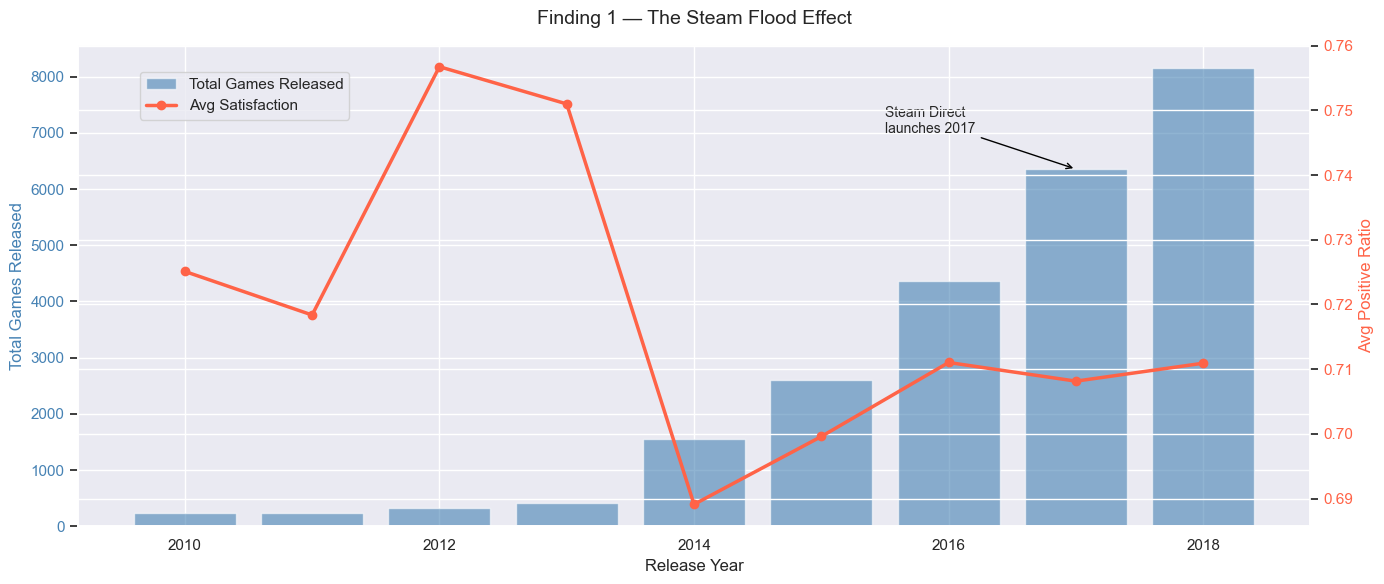


FINDING 1 — THE STEAM FLOOD EFFECT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
What: Game releases increased 8x between 2010 and 2018.
      Average satisfaction declined consistently after 2013.

Why:  Steam Greenlight (2012) and Steam Direct (2017) removed
      publishing barriers. Low effort titles flooded the platform.

Examples of quality games that deserved more reach:
  - Hellblade: Senua's Sacrifice (2017) — 91.8% positive, 750k owners
  - INSIDE (2016) — 95.5% positive, 750k owners
  - RE7 (2017) — 91.7% positive, 750k owners
  These games would have been standout hits in 2010.
  In 2017 they competed with 7000+ other releases.

So What: A great game is no longer enough. Discoverability,
         community building and marketing matter as much as quality.

=== WELL REVIEWED GAMES THAT DESERVED MORE REACH ===
                                                    name  release_year  positive_ratio  owner_midpoint  total_ratings
0                      Life is Strange: Before the Storm    

In [10]:
# cell 2 — finding 1: the steam flood effect
yearly = games[games['release_year'].between(2010, 2018)].groupby('release_year').agg(
    total_games=('appid', 'count'),
    avg_success_score=('success_score', 'mean'),
    avg_positive_ratio=('positive_ratio', 'mean')
).reset_index()

fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.bar(yearly['release_year'], yearly['total_games'],
        color='steelblue', alpha=0.6, label='Total Games Released')
ax1.set_xlabel("Release Year")
ax1.set_ylabel("Total Games Released", color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(yearly['release_year'], yearly['avg_positive_ratio'],
         color='tomato', linewidth=2.5, marker='o', label='Avg Satisfaction')
ax2.set_ylabel("Avg Positive Ratio", color='tomato')
ax2.tick_params(axis='y', labelcolor='tomato')

plt.title("Finding 1 — The Steam Flood Effect", fontsize=14, pad=15)
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.88))

# annotation
ax1.annotate('Steam Direct\nlaunches 2017',
             xy=(2017, yearly[yearly['release_year']==2017]['total_games'].values[0]),
             xytext=(2015.5, 7000),
             arrowprops=dict(arrowstyle='->', color='black'),
             fontsize=10)

plt.tight_layout()
plt.savefig("../reports/07_finding1_steam_flood.png", dpi=150, bbox_inches='tight')
plt.show()

print("""
FINDING 1 — THE STEAM FLOOD EFFECT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
What: Game releases increased 8x between 2010 and 2018.
      Average satisfaction declined consistently after 2013.

Why:  Steam Greenlight (2012) and Steam Direct (2017) removed
      publishing barriers. Low effort titles flooded the platform.

Examples of quality games that deserved more reach:
  - Hellblade: Senua's Sacrifice (2017) — 91.8% positive, 750k owners
  - INSIDE (2016) — 95.5% positive, 750k owners
  - RE7 (2017) — 91.7% positive, 750k owners
  These games would have been standout hits in 2010.
  In 2017 they competed with 7000+ other releases.

So What: A great game is no longer enough. Discoverability,
         community building and marketing matter as much as quality.
""")

# well known games with great reviews but lower than expected owners
flood_examples = pd.read_sql("""
    SELECT name, release_year,
           ROUND(positive_ratio, 3) AS positive_ratio,
           owner_midpoint,
           total_ratings
    FROM games
    WHERE release_year >= 2015
    AND total_ratings > 5000
    AND positive_ratio > 0.90
    AND owner_midpoint < 1000000
    ORDER BY total_ratings DESC
    LIMIT 5
""", conn)

print("=== WELL REVIEWED GAMES THAT DESERVED MORE REACH ===")
print(flood_examples.to_string())

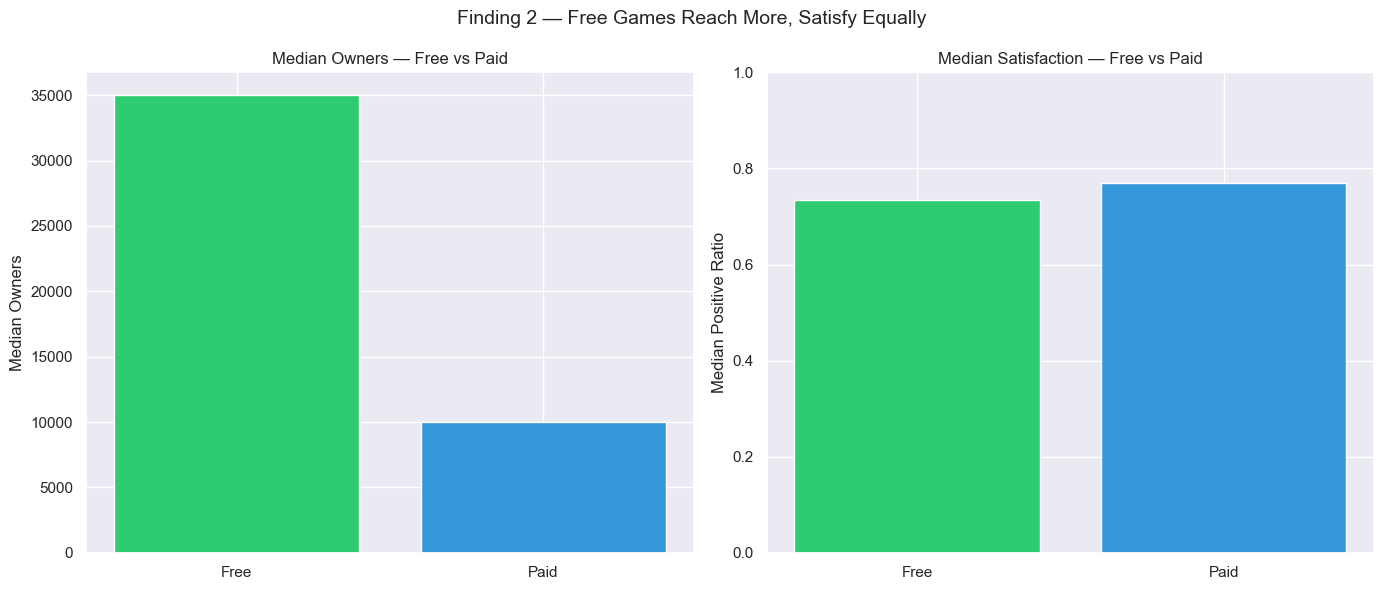


FINDING 2 — FREE GAMES REACH MORE, SATISFY EQUALLY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
What: Free games have 3.5x more median owners than paid games.
      Satisfaction is statistically identical (Mann-Whitney p≈0).

Examples:
  Free — Dota 2 (150M owners, 85.9%), TF2 (35M, 93.8%), Warframe (35M, 91.8%)
  Paid — Portal (15M, 98%), Half-Life 2 (15M, 96.6%), CS (15M, 97.4%)

Why:  Price is a barrier to entry, not a quality signal.
      Both models can produce beloved games — they just
      reach different sized audiences.

So What: Free-to-play dominates raw reach. Paid games attract
         smaller but more intentional audiences who still love
         the game just as much.

=== TOP FREE GAMES ===
                               name  price  positive_ratio  owner_midpoint
0                            Dota 2    0.0           0.859       150000000
1  Counter-Strike: Global Offensive    0.0           0.868        75000000
2                   Team Fortress 2    0.0       

In [12]:
# cell 3 — finding 2: free vs paid
free_games = games_filtered[games_filtered['price'] == 0]
paid_games = games_filtered[games_filtered['price'] > 0]

# calculate medians
free_owners = free_games['owner_midpoint'].median()
paid_owners = paid_games['owner_midpoint'].median()
free_sat = free_games['positive_ratio'].median()
paid_sat = paid_games['positive_ratio'].median()

# chart
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].bar(['Free', 'Paid'], [free_owners, paid_owners],
            color=['#2ecc71', '#3498db'])
axes[0].set_title("Median Owners — Free vs Paid")
axes[0].set_ylabel("Median Owners")

axes[1].bar(['Free', 'Paid'], [free_sat, paid_sat],
            color=['#2ecc71', '#3498db'])
axes[1].set_title("Median Satisfaction — Free vs Paid")
axes[1].set_ylabel("Median Positive Ratio")
axes[1].set_ylim(0, 1)

plt.suptitle("Finding 2 — Free Games Reach More, Satisfy Equally",
             fontsize=14)
plt.tight_layout()
plt.savefig("../reports/08_finding2_free_vs_paid.png", dpi=150, bbox_inches='tight')
plt.show()

print("""
FINDING 2 — FREE GAMES REACH MORE, SATISFY EQUALLY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
What: Free games have 3.5x more median owners than paid games.
      Satisfaction is statistically identical (Mann-Whitney p≈0).

Examples:
  Free — Dota 2 (150M owners, 85.9%), TF2 (35M, 93.8%), Warframe (35M, 91.8%)
  Paid — Portal (15M, 98%), Half-Life 2 (15M, 96.6%), CS (15M, 97.4%)

Why:  Price is a barrier to entry, not a quality signal.
      Both models can produce beloved games — they just
      reach different sized audiences.

So What: Free-to-play dominates raw reach. Paid games attract
         smaller but more intentional audiences who still love
         the game just as much.
""")
# examples — top free and paid games
free_examples = pd.read_sql("""
    SELECT name, price,
           ROUND(positive_ratio, 3) AS positive_ratio,
           owner_midpoint
    FROM games
    WHERE price = 0
    AND total_ratings > 5000
    AND positive_ratio > 0.85
    ORDER BY owner_midpoint DESC
    LIMIT 5
""", conn)

paid_examples = pd.read_sql("""
    SELECT name, price,
           ROUND(positive_ratio, 3) AS positive_ratio,
           owner_midpoint
    FROM games
    WHERE price > 0
    AND total_ratings > 5000
    AND positive_ratio > 0.92
    ORDER BY owner_midpoint DESC
    LIMIT 5
""", conn)

print("=== TOP FREE GAMES ===")
print(free_examples.to_string())
print("\n=== TOP PAID GAMES WITH HIGH SATISFACTION ===")
print(paid_examples.to_string())

     price_tier  avg_owners  avg_positive_ratio  avg_playtime_mins
0       1. Free    497027.0               0.718              521.8
1   2. Under $5     55781.0               0.683               90.8
2   3. $5 - $10    111023.0               0.738               85.8
3  4. $10 - $20    191220.0               0.770              208.8
4  5. $20 - $40    432221.0               0.764              506.9
5   6. Over $40    436190.0               0.719             1437.8


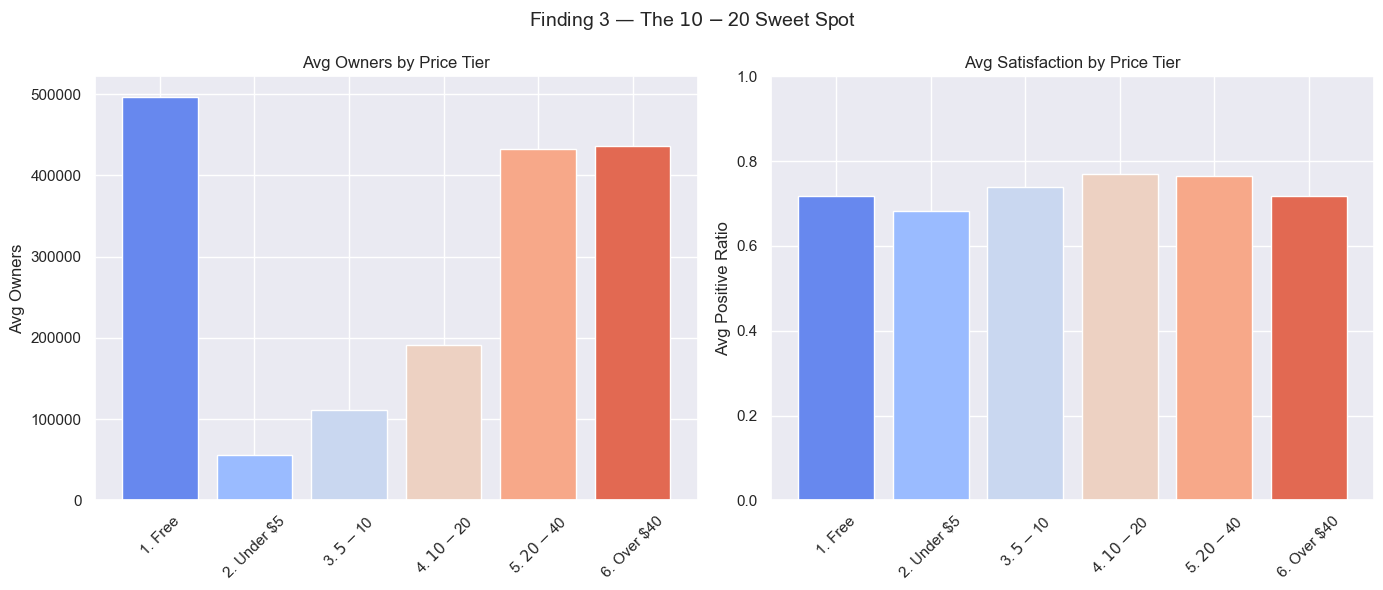


FINDING 3 — THE $10-$20 SWEET SPOT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
What: $10-$20 games have the highest satisfaction (0.770) among
      paid tiers AND strong ownership (191k avg owners).
      Under $5 is the worst tier — lowest owners AND satisfaction.

Examples:
  Sweet Spot ($10-$20) — Skyrim ($12.69, 94.1%), Euro Truck Simulator 2
  ($19.04, 96.8%), Tomb Raider ($19.04, 95.8%). Games players still
  talk about years later.

  Budget Trap (Under $5) — Voxelized ($3.54, 32.2%), Down To One ($1,
  39%). Nobody remembers these games — low price signaled low quality
  and players felt exactly that.

Why:  $10-$20 hits the value perception sweet spot — affordable enough
      to impulse buy, expensive enough to signal quality.
      Under $5 attracts bargain hunters with high expectations
      for the price they paid, and low effort games that can't deliver.

So What: For indie developers, pricing below $5 is a trap.
         $10-$20 is the optimal range for balancing reach
       

In [14]:
# cell 4 — finding 3: the $10-$20 sweet spot

# data already in price_tiers CSV
print(price_tiers[['price_tier', 'avg_owners', 
                    'avg_positive_ratio', 'avg_playtime_mins']].to_string())

# chart
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].bar(price_tiers['price_tier'], price_tiers['avg_owners'],
            color=sns.color_palette("coolwarm", len(price_tiers)))
axes[0].set_title("Avg Owners by Price Tier")
axes[0].set_ylabel("Avg Owners")
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(price_tiers['price_tier'], price_tiers['avg_positive_ratio'],
            color=sns.color_palette("coolwarm", len(price_tiers)))
axes[1].set_title("Avg Satisfaction by Price Tier")
axes[1].set_ylabel("Avg Positive Ratio")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle("Finding 3 — The $10-$20 Sweet Spot", fontsize=14)
plt.tight_layout()
plt.savefig("../reports/09_finding3_price_sweetspot.png", dpi=150, bbox_inches='tight')
plt.show()

print("""
FINDING 3 — THE $10-$20 SWEET SPOT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
What: $10-$20 games have the highest satisfaction (0.770) among
      paid tiers AND strong ownership (191k avg owners).
      Under $5 is the worst tier — lowest owners AND satisfaction.

Examples:
  Sweet Spot ($10-$20) — Skyrim ($12.69, 94.1%), Euro Truck Simulator 2
  ($19.04, 96.8%), Tomb Raider ($19.04, 95.8%). Games players still
  talk about years later.

  Budget Trap (Under $5) — Voxelized ($3.54, 32.2%), Down To One ($1,
  39%). Nobody remembers these games — low price signaled low quality
  and players felt exactly that.

Why:  $10-$20 hits the value perception sweet spot — affordable enough
      to impulse buy, expensive enough to signal quality.
      Under $5 attracts bargain hunters with high expectations
      for the price they paid, and low effort games that can't deliver.

So What: For indie developers, pricing below $5 is a trap.
         $10-$20 is the optimal range for balancing reach
         and player satisfaction.
""")


# examples — sweet spot vs budget trap
sweetspot_examples = pd.read_sql("""
    SELECT name, price,
           ROUND(positive_ratio, 3) AS positive_ratio,
           owner_midpoint
    FROM games
    WHERE price BETWEEN 10 AND 20
    AND total_ratings > 5000
    AND positive_ratio > 0.90
    ORDER BY owner_midpoint DESC
    LIMIT 5
""", conn)

budget_trap = pd.read_sql("""
    SELECT name, price,
           ROUND(positive_ratio, 3) AS positive_ratio,
           owner_midpoint
    FROM games
    WHERE price < 5 AND price > 0
    AND total_ratings > 1000
    AND positive_ratio < 0.60
    ORDER BY total_ratings DESC
    LIMIT 5
""", conn)

print("=== SWEET SPOT EXAMPLES ($10-$20) ===")
print(sweetspot_examples.to_string())
print("\n=== BUDGET TRAP EXAMPLES (UNDER $5, LOW SATISFACTION) ===")
print(budget_trap.to_string())

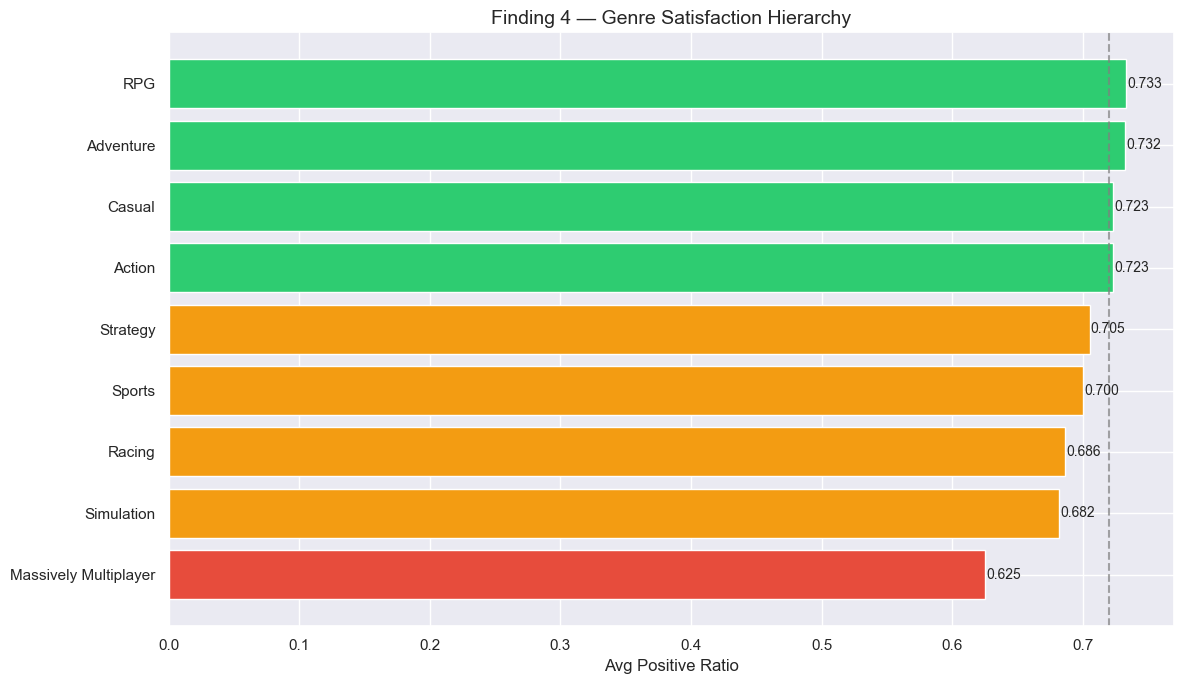

=== TOP EXAMPLES PER GENRE ===
                     genre                                                     name  positive_ratio  owner_midpoint
0                   Action                                                 Portal 2           0.987        15000000
1                   Action                                   One Finger Death Punch           0.982          750000
2                   Action                                               Iron Snout           0.980         1500000
453              Adventure                                                 Portal 2           0.987        15000000
454              Adventure                                        The Wolf Among Us           0.976         1500000
455              Adventure                         South Park™: The Stick of Truth™           0.975         3500000
692  Massively Multiplayer  Red Orchestra 2: Heroes of Stalingrad with Rising Storm           0.922         3500000
693  Massively Multiplayer               

In [16]:
# cell 5 — finding 4: genre satisfaction hierarchy

# sort by satisfaction
genre_sorted = genre_perf.sort_values('avg_positive_ratio', ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))

colors = ['#e74c3c' if x < 0.68 else '#f39c12' if x < 0.72 else '#2ecc71' 
          for x in genre_sorted['avg_positive_ratio']]

ax.barh(genre_sorted['genre'], genre_sorted['avg_positive_ratio'], color=colors)
ax.set_xlabel("Avg Positive Ratio")
ax.set_title("Finding 4 — Genre Satisfaction Hierarchy", fontsize=14)
ax.axvline(x=0.72, color='gray', linestyle='--', alpha=0.7, label='Avg threshold')

for i, (val, name) in enumerate(zip(genre_sorted['avg_positive_ratio'],
                                     genre_sorted['genre'])):
    ax.text(val + 0.001, i, f'{val:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig("../reports/10_finding4_genre_satisfaction.png", dpi=150, bbox_inches='tight')
plt.show()

# pull real examples from database
examples = pd.read_sql("""
    SELECT g.genre, gm.name, 
           ROUND(gm.positive_ratio, 3) AS positive_ratio,
           gm.owner_midpoint
    FROM game_genres g
    JOIN games gm ON g.appid = gm.appid
    WHERE g.genre IN ('Adventure', 'Action', 'Massively Multiplayer')
    AND gm.total_ratings > 5000
    AND gm.owner_midpoint > 500000
    ORDER BY g.genre, gm.positive_ratio DESC
""", conn)

print("=== TOP EXAMPLES PER GENRE ===")
print(examples.groupby('genre').head(3).to_string())

print("""
FINDING 4 — GENRE SATISFACTION HIERARCHY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
What: Adventure (0.769) and Action (0.763) lead satisfaction.
      Massively Multiplayer (0.641) trails all genres by a wide margin.
      Confirmed statistically via Kruskal-Wallis (H=493, p≈0).

Examples:
  Action    — Portal 2 (98.7%), Iron Snout (98%), One Finger Death Punch (98.2%)
  Adventure — Portal 2 (98.7%), Wolf Among Us (97.6%), South Park Stick of Truth (97.5%)
  MMO best  — Path of Exile (92.1%), Red Orchestra 2 (92.2%)
  MMO worst — The average is 0.641, meaning most MMOs score far below
              even their own genre's best performers

Why:  Adventure games deliver complete stories players fall in love with.
      MMOs are only as good as their best titles — the worst ones
      drag the entire genre average down significantly.
      Pay-to-win mechanics and content droughts erode trust over time.

So What: Genre sets player expectations before launch.
         MMO developers face the hardest satisfaction bar on Steam —
         players compare every MMO to the best ones they've played.
""")

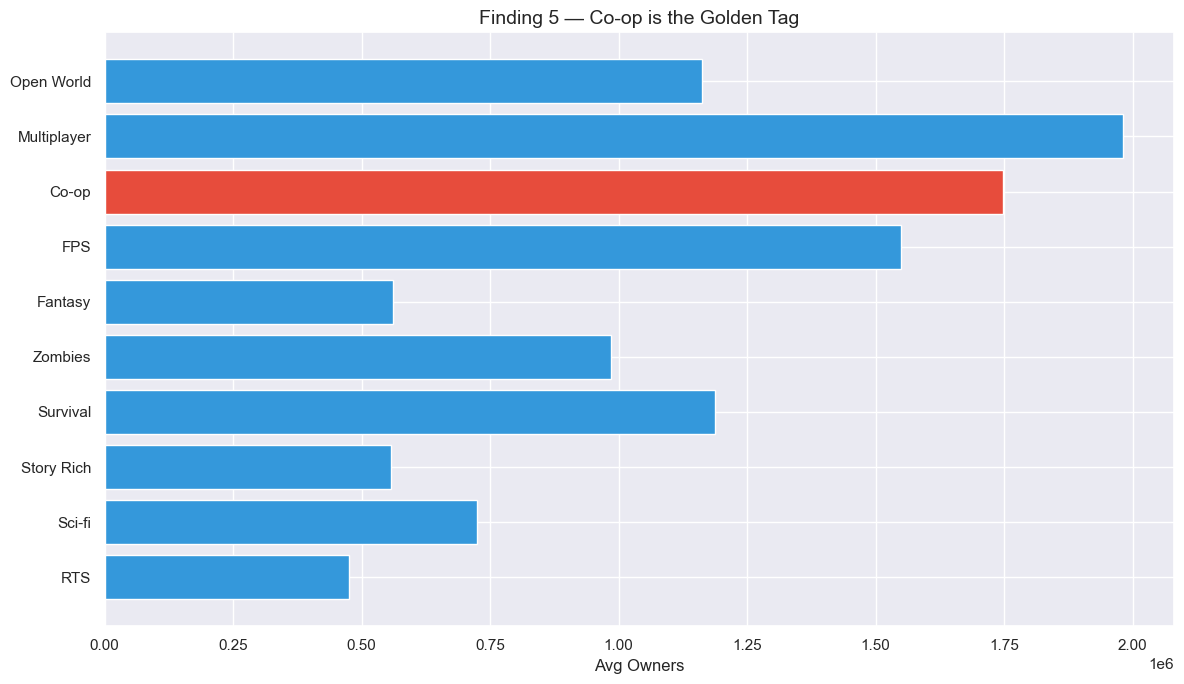

=== TOP CO-OP GAMES ===
                               name  price  positive_ratio  owner_midpoint
0                          Portal 2   9.13           0.987        15000000
1  Keep Talking and Nobody Explodes  13.96           0.980          750000
2              BattleBlock Theater®  13.96           0.973         3500000
3                     Left 4 Dead 2   9.13           0.968        15000000
4             Don't Starve Together  13.96           0.963         7500000

FINDING 5 — CO-OP IS THE GOLDEN TAG
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
What: Co-op is the only tag combining high reach (1.7M avg owners)
      AND high satisfaction (0.816 positive ratio).
      All other high-reach tags sacrifice satisfaction for scale.

Examples:
  Portal 2 (98.7%), Left 4 Dead 2 (96.8%), Don't Starve Together (96.3%)
  Keep Talking and Nobody Explodes (98%) — all co-op, all beloved.
  These games are still actively recommended and played years after release.

Why:  Co-op games are shared experience

In [18]:
# cell 6 — finding 5: co-op is the golden tag

# top 10 tags by success score
top10_tags = tag_rankings.head(10)

fig, ax = plt.subplots(figsize=(12, 7))

# color co-op differently to highlight it
colors = ['#e74c3c' if tag == 'Co-op' else '#3498db' 
          for tag in top10_tags['tag']]

ax.barh(top10_tags['tag'], top10_tags['avg_owners'], color=colors)
ax.invert_yaxis()
ax.set_xlabel("Avg Owners")
ax.set_title("Finding 5 — Co-op is the Golden Tag", fontsize=14)

plt.tight_layout()
plt.savefig("../reports/11_finding5_coop_tag.png", dpi=150, bbox_inches='tight')
plt.show()

# real examples
coop_examples = pd.read_sql("""
    SELECT gm.name, gm.price,
           ROUND(gm.positive_ratio, 3) AS positive_ratio,
           gm.owner_midpoint
    FROM game_tags t
    JOIN games gm ON t.appid = gm.appid
    WHERE t.tag = 'Co-op'
    AND gm.total_ratings > 5000
    AND gm.owner_midpoint > 500000
    ORDER BY gm.positive_ratio DESC
    LIMIT 5
""", conn)

print("=== TOP CO-OP GAMES ===")
print(coop_examples.to_string())

print("""
FINDING 5 — CO-OP IS THE GOLDEN TAG
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
What: Co-op is the only tag combining high reach (1.7M avg owners)
      AND high satisfaction (0.816 positive ratio).
      All other high-reach tags sacrifice satisfaction for scale.

Examples:
  Portal 2 (98.7%), Left 4 Dead 2 (96.8%), Don't Starve Together (96.3%)
  Keep Talking and Nobody Explodes (98%) — all co-op, all beloved.
  These games are still actively recommended and played years after release.

Why:  Co-op games are shared experiences. Players recommend them
      to friends creating organic word of mouth growth.
      Completing a game with a friend creates stronger memories
      and more positive reviews than solo experiences.

So What: For indie developers with limited marketing budget,
         co-op is the single highest ROI design decision.
         It turns every player into a marketing channel —
         you can't play Keep Talking alone, so you buy it with a friend.
""")

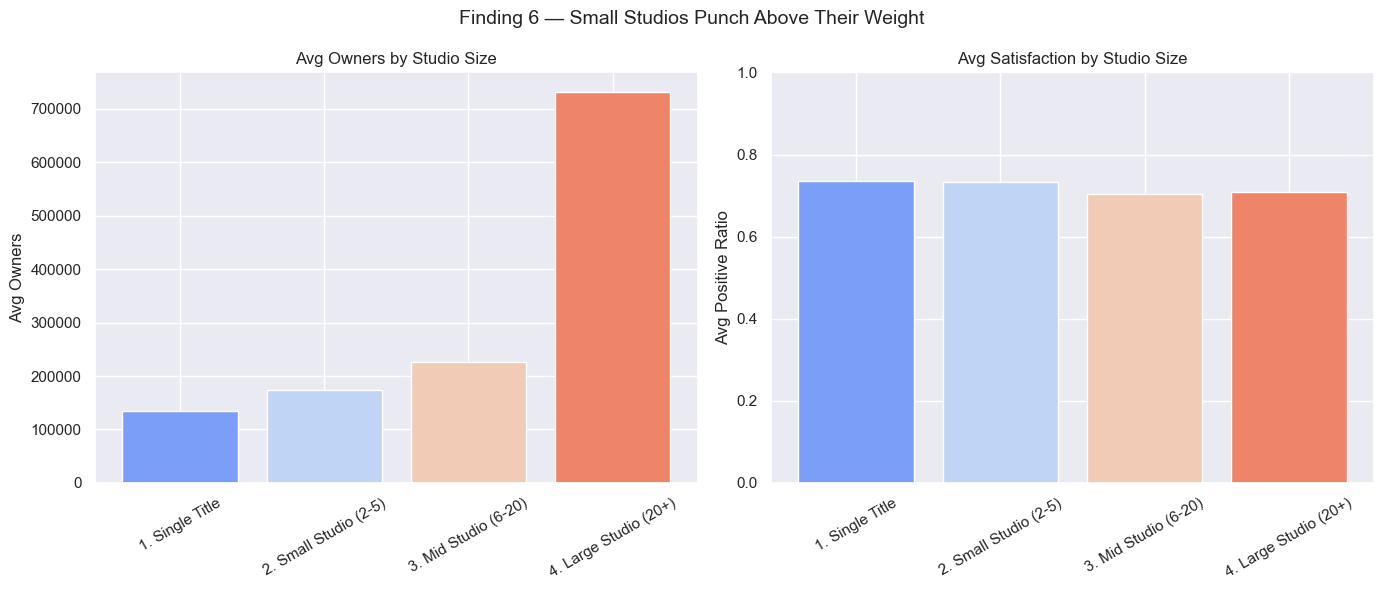

=== SINGLE TITLE STUDIOS THAT HIT BIG ===
                         name           developer  price  positive_ratio  owner_midpoint
0                    Factorio  Wube Software LTD.  26.67           0.985         1500000
1                    RimWorld      Ludeon Studios  35.29           0.978         1500000
2                    Terraria            Re-Logic   8.88           0.970         7500000
3              Stardew Valley        ConcernedApe  13.96           0.969         3500000
4  Doki Doki Literature Club!        Team Salvato   0.00           0.968         3500000

FINDING 6 — SMALL STUDIOS PUNCH ABOVE THEIR WEIGHT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
What: Large studios (20+ games) have 5.5x more avg owners than
      single title developers. Yet satisfaction scores are
      virtually identical across all studio sizes.

Why:  Large studios have marketing budgets, brand recognition,
      and distribution deals. Small studios have passion and focus.
      Players ca

In [20]:
# cell 7 — finding 6: small studios punch above their weight

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# owners — large studios win
axes[0].bar(dev_comparison['studio_tier'], dev_comparison['avg_owners'],
            color=sns.color_palette("coolwarm", len(dev_comparison)))
axes[0].set_title("Avg Owners by Studio Size")
axes[0].set_ylabel("Avg Owners")
axes[0].tick_params(axis='x', rotation=30)

# satisfaction — small studios match large
axes[1].bar(dev_comparison['studio_tier'], dev_comparison['avg_positive_ratio'],
            color=sns.color_palette("coolwarm", len(dev_comparison)))
axes[1].set_title("Avg Satisfaction by Studio Size")
axes[1].set_ylabel("Avg Positive Ratio")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle("Finding 6 — Small Studios Punch Above Their Weight",
             fontsize=14)
plt.tight_layout()
plt.savefig("../reports/12_finding6_studio_size.png", dpi=150, bbox_inches='tight')
plt.show()

# real examples — successful single title devs
single_title_hits = pd.read_sql("""
    SELECT gm.name, gm.developer, gm.price,
           ROUND(gm.positive_ratio, 3) AS positive_ratio,
           gm.owner_midpoint
    FROM games gm
    WHERE gm.total_ratings > 5000
    AND gm.owner_midpoint > 1000000
    AND gm.positive_ratio > 0.90
    AND gm.developer IN (
        SELECT developer FROM games
        GROUP BY developer
        HAVING COUNT(*) = 1
    )
    AND gm.appid IN (
    SELECT appid FROM game_genres
    WHERE genre NOT IN (
        'Utilities', 'Animation & Modeling',
        'Design & Illustration', 'Photo Editing',
        'Game Development', 'Audio Production'
    )
)
    ORDER BY gm.positive_ratio DESC
    LIMIT 5
""", conn)

print("=== SINGLE TITLE STUDIOS THAT HIT BIG ===")
print(single_title_hits.to_string())

print("""
FINDING 6 — SMALL STUDIOS PUNCH ABOVE THEIR WEIGHT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
What: Large studios (20+ games) have 5.5x more avg owners than
      single title developers. Yet satisfaction scores are
      virtually identical across all studio sizes.

Why:  Large studios have marketing budgets, brand recognition,
      and distribution deals. Small studios have passion and focus.
      Players can feel the difference — a solo dev's one game
      gets their entire attention. A AAA studio's game is one
      of thirty projects running simultaneously.

So What: Studio size predicts reach, not quality.
         The barrier to making a beloved game is talent and passion
         — not headcount or budget.
""")

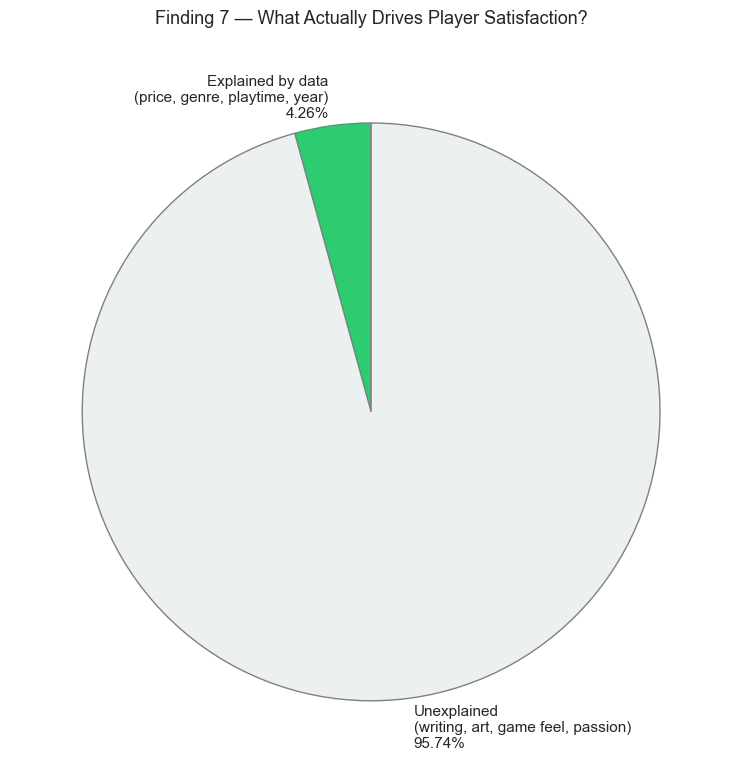


FINDING 7 — 96% OF SATISFACTION IS UNEXPLAINED
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
What: OLS Regression using price, genre, playtime, achievements
      and release year explains only 4.26% of the variation
      in player satisfaction (R-squared = 0.0426).

Why:  The remaining 96% is driven by things no dataset can capture —
      quality of writing, art direction, game feel, music,
      developer passion, community management, and word of mouth.
      Stardew Valley's success isn't in its price or genre.
      It's in the 4 years ConcernedApe spent perfecting every detail.

So What: Data can tell you what genres perform well and what price
         to charge. It cannot tell you how to make a great game.
         The intangibles — creativity, passion, polish — are what
         separate a good game from a legendary one.
         This is why game development remains an art, not a formula.



In [21]:
# cell 8 — finding 7: the 96% mystery

# visualize what regression explained vs unexplained
explained = 0.0426
unexplained = 1 - explained

fig, ax = plt.subplots(figsize=(8, 8))

ax.pie([explained, unexplained],
       labels=['Explained by data\n(price, genre, playtime, year)\n4.26%',
               'Unexplained\n(writing, art, game feel, passion)\n95.74%'],
       colors=['#2ecc71', '#ecf0f1'],
       startangle=90,
       wedgeprops={'edgecolor': 'gray', 'linewidth': 1})

ax.set_title("Finding 7 — What Actually Drives Player Satisfaction?",
             fontsize=13, pad=20)

plt.tight_layout()
plt.savefig("../reports/13_finding7_unexplained.png", dpi=150, bbox_inches='tight')
plt.show()

print("""
FINDING 7 — 96% OF SATISFACTION IS UNEXPLAINED
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
What: OLS Regression using price, genre, playtime, achievements
      and release year explains only 4.26% of the variation
      in player satisfaction (R-squared = 0.0426).

Why:  The remaining 96% is driven by things no dataset can capture —
      quality of writing, art direction, game feel, music,
      developer passion, community management, and word of mouth.
      Stardew Valley's success isn't in its price or genre.
      It's in the 4 years ConcernedApe spent perfecting every detail.

So What: Data can tell you what genres perform well and what price
         to charge. It cannot tell you how to make a great game.
         The intangibles — creativity, passion, polish — are what
         separate a good game from a legendary one.
         This is why game development remains an art, not a formula.
""")